(qr-section)=

# QR decomposition

QR decomposition is another decomposition method that factorises a matrix in the product of two matrices $Q$ and $R$ such that

$$ \begin{align*}
    A = QR,
\end{align*} $$

where $Q$ is an orthogonal matrix and $R$ is an upper triangular matrix.

````{prf:definition} Orthogonal vectors
:label: orthogonal-vector-definition

A set of vectors $\lbrace \mathbf{v}_1 ,\mathbf{v}_2 ,\mathbf{v}_3 ,\dots \rbrace$ is said to be **orthogonal** if $\mathbf{v}_i \cdot \mathbf{v}_j =0$ for $i\not= j$. Furthermore the set is said to be **orthonormal** if $\mathbf{v}_i$ are all unit vectors.
````

````{prf:definition} Orthogonal matrix
:label: orthogonal-matrix-definition

An **orthogonal matrix** is a matrix where the columns are a set of orthonormal vectors. If $A$ is an orthogonal matrix if

$$ \begin{align*}
    A^\mathsf{T} A=I.
\end{align*} $$
````

For example consider the matrix

$$ \begin{align*}
    A= \begin{pmatrix}
        0.8 & -0.6\\
        0.6 & 0.8
    \end{pmatrix}.
\end{align*} $$

This is an orthogonal matrix since

$$ \begin{align*}
    A^\mathsf{T} A=\begin{pmatrix}
        0.8 & 0.6\\
        -0.6 & 0.8
    \end{pmatrix}
    \begin{pmatrix}
        0.8 & -0.6\\
        0.6 & 0.8
    \end{pmatrix} = 
    \begin{pmatrix}
        1 & 0\\
        0 & 1
    \end{pmatrix}=I.
\end{align*} $$

Futhermore it is an orthonormal matrix since the magnitude of the columns for $A$ are both 1.

---

(qr-gramschmidt-section)=

## QR decomposition using the Gram-Schmidt process

Consider the $3 \times 3$ matrix $A$ represented as the concatenation of the column vectors $\mathbf{a}_1, \mathbf{a}_2, \mathbf{a}_3$

$$ \begin{pmatrix}
    a_{11} & a_{12} & a_{13} \\
    a_{21} & a_{22} & a_{23} \\
    a_{31} & a_{32} & a_{33}
\end{pmatrix} =
\begin{pmatrix}
    \uparrow & \uparrow & \uparrow \\
    \mathbf{a}_1 & \mathbf{a}_2 & \mathbf{a}_3 \\
    \downarrow & \downarrow & \downarrow
\end{pmatrix} $$

where $\mathbf{a}_j = (a_{1j}, a_{2j}, a_{3j})$. To calculate the orthogonal $Q$ matrix we need a set of vectors $\{\mathbf{q}_1, \mathbf{q}_2, \mathbf{q}_3\}$ that span the same space as $\{\mathbf{a}_1, \mathbf{a}_2, \mathbf{a}_3\}$ but are orthogonal to each other. One way to do this is using the **Gram-Schmidt process**. Consider the diagram shown in {numref}`gram-schmidt-figure` that shows the first two non-orthogonal vectors $\mathbf{a}_1$ and $\mathbf{a}_2$. 

```{figure} ../_images/gram_schmidt.svg
:name: gram-schmidt-figure
:width: 400

The Gram-Schmidt process
```

We begin by letting $\mathbf{u}_1 = \mathbf{a}_1$ and seek to find a vector $\mathbf{u}_2$ that is orthogonal to $\mathbf{u}_1$ and in the same span as $\mathbf{a}_2$. To do this we subtract the <a href="https://en.wikipedia.org/wiki/Vector_projection" target="_blank">vector projection</a> of $\mathbf{a}_2$ onto $\mathbf{u}_1$, i.e.,

$$ \mathbf{u}_2 = \mathbf{a}_2 - \left( \frac{\mathbf{q}_1 \cdot \mathbf{a}_1}{\mathbf{q}_1 \cdot \mathbf{u}_1} \right) \mathbf{u}_1.$$

We can simplify things by normalising $\mathbf{u}_1$ such that $\mathbf{q}_1 = \dfrac{\mathbf{u}_1}{\|\mathbf{u}_1\|}$ so we have

$$ \mathbf{u}_2 = \mathbf{a}_2 - (\mathbf{q}_1 \cdot \mathbf{a}_2) \mathbf{q}_1, $$(gramschmidt-u2-equation)

which we also normalise to give $\mathbf{q}_2 = \dfrac{\mathbf{u}_2}{\|\mathbf{u}_2\|}$. For the next vector $\mathbf{a}_3$ we want the vector $\mathbf{u}_3$ to be orthogonal to both $\mathbf{q}_1$ and $\mathbf{q}_2$ so we subtract both the vector projections of $\mathbf{a}_3$ onto $\mathbf{q}_1$ and $\mathbf{q}_2$

$$ \mathbf{u}_3 = \mathbf{a}_3 - (\mathbf{q}_1 \cdot \mathbf{a}_3) \mathbf{q}_1 - (\mathbf{q}_2 \cdot \mathbf{a}_3) \mathbf{q}_2, $$(gramschmidt-u3-equation)

which is normalised to give $\mathbf{q}_3$. Using $\mathbf{u}_i = (\mathbf{q}_i \cdot \mathbf{a}_i) \mathbf{q}_i$ and rearranging {eq}`gramschmidt-u2-equation` and {eq}`gramschmidt-u3-equation` to make $\mathbf{a}_i$ the subject and 

$$ \begin{align*}
  \mathbf{a}_1 &= (\mathbf{q}_1 \cdot \mathbf{a}_1), \\
  \mathbf{a}_2 &= (\mathbf{q}_1 \cdot \mathbf{a}_2) \mathbf{q}_1 + (\mathbf{q}_2 \cdot \mathbf{a}_2) \mathbf{q}_2, \\
  \mathbf{a}_3 &= (\mathbf{q}_1 \cdot \mathbf{a}_3) \mathbf{q}_1 + (\mathbf{q}_2 \cdot \mathbf{a}_3) \mathbf{q}_2 + (\mathbf{q}_3 \cdot \mathbf{a}_3) \mathbf{q}_3, \\
  & \vdots 
\end{align*} $$

The columns of the $Q$ matrix are formed using the vectors $\mathbf{q}_i$ 

$$ Q = 
\begin{pmatrix}
    \uparrow & \uparrow & & \uparrow \\
    \mathbf{q}_1 & \mathbf{q}_2 & \cdots & \mathbf{q}_n \\
    \downarrow & \downarrow & & \downarrow
\end{pmatrix}, $$

and the elements of the $R$ matrix are formed from the dot products of the $\mathbf{q}_i$ and $\mathbf{a}_j$ vectors such that

$$ R = \begin{pmatrix}
  (\mathbf{q}_1 \cdot \mathbf{a}_1) & (\mathbf{q}_1 \cdot \mathbf{a}_2) & \cdots & (\mathbf{q}_1 \cdot \mathbf{a}_n) \\
  0 & (\mathbf{q}_2 \cdot \mathbf{a}_2) & \cdots & (\mathbf{q}_1 \cdot \mathbf{a}_n) \\
  \vdots & \ddots & \ddots & \vdots \\
  0 & \cdots & 0 & (\mathbf{q}_n \cdot \mathbf{a}_n)
\end{pmatrix}. $$

### Positive diagonal elements of $R$

It has become standard convention to impose a condition that the diagonal elements of $R$ must be positive so that we get a unique factorisation. Consider $A = QR$ then multiplying a column of $Q$ by $-1$ and the corresponding row of $R$ by $-1$ doesn't change the product $QR$. So if any of the diagonal elements of $R$ are negative we multiply the corresponding column of $Q$ and row of $R$ by $-1$.

  
```{prf:algorithm} QR decomposition using the Gram-Schmidt process
:label: qr-gramschmidt-algorithm

**Inputs:** An $m \times n$ matrix $A$.

**Outputs:** An $m \times n$ orthogonal matrix $Q$ and and $n \times n$ upper triangular matrix $R$ such that $A = QR$.

- For $j = 1, \ldots, n$ do
  - For $i = 1, \ldots, j - 1$ do
    - $r_{ij} \gets \mathbf{q}_i \cdot \mathbf{a}_j$ 
  - $\mathbf{u}_j \gets \mathbf{a}_j - \displaystyle\sum_{i=1}^{j-1} r_{ij} \mathbf{q}_i$
  - $r_{jj} \gets \| \mathbf{u}_j \|$
  - $\mathbf{q}_j \gets \dfrac{\mathbf{u}_j}{r_{jj}}$
- $Q \gets (\mathbf{q}_1, \mathbf{q}_2, \ldots, \mathbf{q}_2)$

- For $i = 1, \ldots, n$ do
  - If $r_{ii} < 0$ then
    - $R(i,: ) \gets -R(i,:)$
    - $Q(:,i) \gets -Q(:,i)$

- Return $Q$ and $R$
```
 
```{prf:example}
:label: qr-gramschmidt-example

Calculate the QR decomposition of the following matrix using the Gram-Schmidt process

$$ \begin{align*}
    A  = \begin{pmatrix}
        -1 & -1 & 1 \\
        1 & 3 & 3 \\
        -1 & -1 & 5 \\
        1 & 3 & 7
    \end{pmatrix}.
\end{align*} $$

---

**Solution**


$$ \begin{align*}
  j &= 1: & \mathbf{u}_1 &= \mathbf{a}_1 = \begin{pmatrix} -1 \\ 1 \\ -1 \\ 1 \end{pmatrix}, \\
  && r_{11} &= \| \mathbf{u}_1 \| = 2, \\
  && \mathbf{q}_1 &= \frac{\mathbf{u}_1}{r_{11}} = \frac{1}{2} \begin{pmatrix} -1 \\ 1 \\ 1 \\ 1 \end{pmatrix} = \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix}. \\
  j &= 2: & r_{12} &= \mathbf{q}_1 \cdot \mathbf{a}_2 = 
  \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix} \cdot \begin{pmatrix} -1 \\ 3 \\ -1 \\ 3 \end{pmatrix} = 4, \\
  && \mathbf{u}_2 &= \mathbf{a}_2 - r_{12} \mathbf{q}_1 = 
  \begin{pmatrix} -1 \\ 3 \\ -1 \\ 3 \end{pmatrix} - 4 
  \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix} = 
  \begin{pmatrix} 1 \\ 1 \\ 1 \\ 1 \end{pmatrix}, \\
  && r_{22} &= \| \mathbf{u}_2 \| = 2, \\
  && \mathbf{q}_2 &= \frac{\mathbf{u}_2}{r_{22}} = \frac{1}{2}
  \begin{pmatrix} 1 \\ 1 \\ 1 \\ 1 \end{pmatrix} = 
  \begin{pmatrix} \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \end{pmatrix}. \\
  j &= 3: & r_{13} &= \mathbf{q}_1 \cdot \mathbf{a}_3 = 
  \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix} \cdot
  \begin{pmatrix} 1 \\ 3\\ 5 \\ 7 \end{pmatrix} = 2, \\
  && r_{23} &= \mathbf{q}_2 \cdot \mathbf{a}_3 = 
  \begin{pmatrix} \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \end{pmatrix} \cdot
  \begin{pmatrix} 1 \\ 3 \\ 5 \\ 7 \end{pmatrix} = 8, \\
  && \mathbf{u}_3 &= \mathbf{a}_3 - r_{13} \mathbf{q}_1 - r_{23} \mathbf{q}_2 =
  \begin{pmatrix} 1 \\ 3 \\ 5 \\ 7 \end{pmatrix} - 2
  \begin{pmatrix} -\frac{1}{2} \\ \frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \end{pmatrix} - 8
  \begin{pmatrix} \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \end{pmatrix} = 
  \begin{pmatrix} -2 \\ -2 \\ 2 \\ 2 \end{pmatrix}, \\
  && r_{33} &= \| \mathbf{u}_3 \| = 4, \\
  && \mathbf{q}_3 &= \frac{\mathbf{u}_3}{r_{33}} = \frac{1}{4} 
  \begin{pmatrix} -2 \\ -2 \\ 2 \\ 2 \end{pmatrix} =
  \begin{pmatrix} -\frac{1}{2} \\ -\frac{1}{2} \\ \frac{1}{2} \\ \frac{1}{2} \end{pmatrix}. 
\end{align*} $$

The diagonal elements of $R$ are all positive so we don't need to make any adjustments. Thus the $Q$ and $R$ matrices are given by

$$ \begin{align*}
  Q &= \begin{pmatrix}
    -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    -\frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & \frac{1}{2}
  \end{pmatrix}, &
  R &= 
  \begin{pmatrix}
    2 & 4 & 2 \\
    0 & 2 & 8 \\
    0 & 0 & 4
  \end{pmatrix}.
\end{align*} $$

We can check that this is correct by verifying that $A = QR$ and that $Q^\mathsf{T}Q = I$.

$$ \begin{align*}
  \begin{pmatrix}
    -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    -\frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & \frac{1}{2}
  \end{pmatrix}
  \begin{pmatrix}
    2 & 4 & 2 \\
    0 & 2 & 8 \\
    0 & 0 & 4
  \end{pmatrix} &=
  \begin{pmatrix}
    -1 & -1 & 1 \\
    1 & 3 & 3 \\
    -1 & -1 & 5 \\
    1 & 3 & 7
  \end{pmatrix} = A, \\
  \begin{pmatrix}
    -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\
    -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & \frac{1}{2}
  \end{pmatrix}
  \begin{pmatrix}
    -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\
    -\frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\
    \frac{1}{2} & \frac{1}{2} & \frac{1}{2}
  \end{pmatrix} &=
  \begin{pmatrix}
    1 & 0 & 0 \\
    0 & 1 & 0 \\
    0 & 0 & 1
  \end{pmatrix} = I.
\end{align*} $$
```

### Code

The code below defines a function called `qr_gramschmidt()` which calculates the QR decomposition of a matrix `A` using the Gram-Schmidt process.

`````{tab-set}
````{tab-item} Python
```python
def qr_gramschmidt(A):

    n = A.shape[1]
    Q, R = np.copy(A).astype(float), np.zeros((n,n))

    for j in range(n):
        for i in range(j):
            R[i,j] = np.dot(Q[:,i], A[:,j])
            Q[:,j] = Q[:,j] - R[i,j] * Q[:,i]
        
        R[j,j] = np.linalg.norm(Q[:,j])
        Q[:,j] = Q[:,j] / R[j,j]

    for i in range(n):
        if R[i,i] < 0:
            R[i,:] *= -1
            Q[:,i] *= -1

    return Q, R
```
````

````{tab-item} MATLAB
```matlab
function [Q, R] = qr_gramschmidt(A)

[~, n] = size(A);
Q = A;
R = zeros(n, n);

for j = 1 : n
    for i = 1 : j - 1
        R(i,j) = dot(Q(:,i), A(:,j));
        Q(:,j) = Q(:,j) - R(i,j) * Q(:,i);
    end

    R(j,j) = norm(Q(:,j));
    Q(:,j) = Q(:,j) / R(j,j);
end

for i = 1 : n
    if R(i,i) < 0
        R(i,:) = -R(i,:);
        Q(:,i) = -Q(:,i);
    end
end

end
```
````
`````

In [1]:
import numpy as np

def qr_gramschmidt(A):
    m, n = A.shape
    Q, R = np.copy(A).astype(float), np.zeros((n,n))
    for j in range(n):
        for i in range(j):
            R[i,j] = np.dot(Q[:,i], A[:,j])
            Q[:,j] = Q[:,j] - R[i,j] * Q[:,i]
        
        R[j,j] = np.linalg.norm(Q[:,j])
        Q[:,j] = Q[:,j] / R[j,j]

    for i in range(n):
        for j in range(i):
            if R[j,j] < 0:
                R[j,:] *= -1
                Q[:,j] *= -1

    return Q, R

# Define matrix
A = np.array([[-1, -1, 1], 
              [1, 3, 3], 
              [-1, -1, 5], 
              [1, 3, 7]])

# Calculate QR decomposition
Q, R = qr_gramschmidt(A)
print(f"Q = \n{Q}\n\nR = \n{R}")

Q = 
[[-0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5]
 [-0.5  0.5  0.5]
 [ 0.5  0.5  0.5]]

R = 
[[2. 4. 2.]
 [0. 2. 8.]
 [0. 0. 4.]]


(qr-householder-section)=

## QR decomposition using Householder reflections

Another method we can use to calculate the QR decomposition of a matrix is by the use of **Householder reflections**. 

```{prf:definition} Householder matrix

The Householder matrix is an orthogonal reflection matrix of the form

$$ H = I - 2 \frac{\mathbf{v} \mathbf{v}^\mathsf{T}}{\mathbf{v}^\mathsf{T} \mathbf{v}}, $$(householder-equation)

where $\mathbf{v}$ is a non-zero column vector. The matrix $H$ is symmetric and orthogonal.
```

```{figure} ../_images/householder_1.svg
:name: householder-1-figure
:width: 350

The vector $\mathbf{x}$ is reflected about the dashed line so that it is parallel to the basis vector $\mathbf{e}_1$.
```

Consider the diagram in {numref}`householder-1-figure` where the vector $\mathbf{x}$ is reflected about the hyperplane represented by the dashed line so that it is parallel to the first basis vector of the standard basis $\mathbf{e}_1 = (1, 0, \ldots, 0)^\mathsf{T}$. The Householder matrix that achieves this reflection is written in terms of the vector $\mathbf{v}$ which is orthogonal to the dashed line and calculated using

$$ \mathbf{v} = \mathbf{x} - \|\mathbf{x}\|\mathbf{e}_1. $$

If the magnitude of $\mathbf{x}$ is close to being parallel to $\mathbf{e}_1$ then $\mathbf{v}$ will be close to $\mathbf{0}$ and the calculation of {eq}`householder-equation` will involve the division by a number close to zero. To overcome this we use a Householder transformation to reflect $\mathbf{x}$ so that it is parallel to $-\mathbf{e}_1$ instead of $+\mathbf{e}_1$. 

```{figure} ../_images/householder_2.svg
:name: householder-2-figure
:width: 450

The vector $\mathbf{x}$ is reflected about the dashed line so that it is parallel to the basis vector $-\mathbf{e}_1$.
```

To do this we calculate $\mathbf{v}$ by adding $\| \mathbf{x} \| \mathbf{e}_1$ to $ \mathbf{x}$ when the sign of $x_1$ is negative, i.e.,

$$ \mathbf{v} = \mathbf{x} - \operatorname{sign}(x_1) \| \mathbf{x} \| \mathbf{e}_1, $$

where $\operatorname{sign}(x)$ returns $+1$ if $x \geq 0$ and $-1$ if $x < 0$. To compute the QR decomposition of a matrix $A$, we reflect the first column of $A$, using Householder reflection so that it is parallel to $\mathbf{e}_1$. This means that $r_{11}$ is the only non-zero element in the first column of $R$.

$$ \begin{align*}
  R = H_1 A = 
  \begin{pmatrix}
    r_{11} & r_{12} & r_{13} & \cdots & r_{1n} \\
    0 & b_{22} & b_{23} & \cdots & b_{2n} \\
    0 & b_{32} & b_{33} & \cdots & b_{3n} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    0 & b_{m2} & b_{m3} & \cdots & b_{mn}
  \end{pmatrix}
\end{align*} $$

We then look to do the same for the sub-matrix of $R$ formed by omitted its first row and column. We do this by calculating a $(m-1) \times (m-1)$ Householder matrix $H'$ using the second column of $R$ starting from the diagonal element, i.e., $\mathbf{x} = (b_{22}, b_{32}, \ldots, b_{m2})^\mathsf{T}$. This is used to form the $m \times m$ Householder matrix $H_2$ by padding out the first row and column of the identity matrix.

$$ \begin{align*}
  H_2 = \begin{pmatrix} 
    1 & \begin{matrix} 0 & \cdots & 0 \end{matrix} \\
    \begin{matrix} 0 \\ \vdots \\ 0 \end{matrix} & H'
  \end{pmatrix}
\end{align*} $$

The Householder matrix $H_2$ is then applied to $R$ so that the elements of the second column below the diagonal are zeroed out. 

$$ \begin{align*}
  R = H_2 R = 
  \begin{pmatrix}
    r_{11} & r_{12} & r_{13} & \cdots & r_{1n} \\
    0 & r_{22} & r_{23} & \cdots & r_{2n} \\
    0 & 0 & c_{33} &\cdots & c_{3n} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    0 & 0 & c_{n3} & \cdots & c_{nn}
  \end{pmatrix}
\end{align*} $$

We repeat this process until column $j = m - 1$ when $R$ will be an upper triangular matrix. If $A$ has $n$ columns then 

$$R = H_{m-1}\ldots H_2 H_1 A,$$

rearranging gives

$$\begin{align*}
  H_1^{-1} H_2^{-1} \ldots H_{m-1}^{-1} R = A.
\end{align*} $$

The Householder matrices are symmetric and orthogonal so $H^{-1} = H$ and since we want $A = QR$ then

$$ \begin{align*}
  Q = H_1H_2 \ldots H_{m-1}.
\end{align*} $$

```{prf:algorithm} QR decomposition using Householder reflections
:label: qr-householder-algorithm

**Inputs:** An $m \times n$ matrix $A$.

**Outputs:** An $n \times n$ orthogonal matrix $Q$ and and $n \times n$ upper triangular matrix $R$ such that $A = QR$.

- $Q \gets I_m$
- $R \gets A$
- For $j = 1, \ldots, m - 1$ do
  - $\mathbf{x} \gets$ column $j$ of $R$ starting at the $j$-th row
  - $\mathbf{v} \gets \mathbf{x} - \operatorname{sign} (x_1) \|\mathbf{x}\|\mathbf{e}_1$
  - $H' \gets I_{m-j+1} - 2 \dfrac{\mathbf{v} \mathbf{v} ^\mathsf{T}}{\mathbf{v}^\mathsf{T} \mathbf{v}}$
  - $H(j:m, j:m) \gets H'$ with the first $j-1$ rows and columns of $H$ set to those of $I_m$
  - $R \gets H R$
  - $Q \gets Q H$
  
- For $i = 1, \ldots, n$ do
  - If $R(i,i) < 0$ then
    - $R(i,: ) \gets -R(i,:)$
    - $Q(:,i) \gets -Q(:,i)$

- Return $Q$ and $R$.
```

```{prf:example}
:label: qr-householder-example

Calculate the QR decomposition of the following matrix using Householder reflections

$$ \begin{align*}
  A=\begin{pmatrix}
    1 & -4 \\
    2 & 3 \\
    2 & 2
  \end{pmatrix}.
\end{align*} $$

---

**Solution**

Set $Q = I$ and $R = A$. We want to zero out the elements below $R(1,1)$ so $\mathbf{x} = (1, 2, 2)^\mathsf{T}$ and $\|\mathbf{x}\| = 3$.

$$ \begin{align*}
  j &= 1: & \mathbf{x} &= 
  \begin{pmatrix} 1 \\ 2 \\ 2 \end{pmatrix}, \\
  && \mathbf{v} &= \mathbf{x} - \operatorname{sign}(x_1) \|\mathbf{x}\| \mathbf{e}_1 = 
  \begin{pmatrix} 1 \\ 2 \\ 2 \end{pmatrix} - 3 
  \begin{pmatrix} 1 \\ 0 \\ 0 \end{pmatrix} = 
  \begin{pmatrix} -2 \\ 2 \\ 2 \end{pmatrix}, \\
  && H &= I - 2 \frac{\mathbf{v} \mathbf{v}^\mathsf{T}}{\mathbf{v}^\mathsf{T} \mathbf{v}} = 
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & 1 & 0 \\ 
    0 & 0 & 1 
  \end{pmatrix} - \frac{2}{12}
  \begin{pmatrix} 
    4 & -4 & -4 \\
    -4 & 4 & 4 \\
    -4 & 4 & 4
  \end{pmatrix} =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{1}{3} & -\frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{3} & \frac{1}{3} 
  \end{pmatrix}, \\
  && R &= H R =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{1}{3} & -\frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{3} & \frac{1}{3} 
  \end{pmatrix}
  \begin{pmatrix}
    1 & -4 \\
    2 & 3 \\
    2 & 2
  \end{pmatrix} =
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & -3 \\ 
    0 & -4
  \end{pmatrix}, \\
  && Q &= QH =
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & 1 & 0 \\ 
    0 & 0 & 1 
  \end{pmatrix}
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{1}{3} & -\frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{3} & \frac{1}{3} 
  \end{pmatrix} =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{1}{3} & -\frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{3} & \frac{1}{3} 
  \end{pmatrix}. \\
  j &= 2: & \mathbf{x} &= 
  \begin{pmatrix} -3 \\ -4 \end{pmatrix}, \\
  && \mathbf{v} &= \mathbf{x} - \operatorname{sign}(x_1) \|\mathbf{x}\| \mathbf{e}_1 = 
  \begin{pmatrix} -3 \\ -4 \end{pmatrix} + 5 
  \begin{pmatrix} 1 \\ 0 \end{pmatrix} = 
  \begin{pmatrix} 2 \\ -4 \end{pmatrix}, \\
  && H' &= I - 2 \frac{\mathbf{v}\mathbf{v}^\mathsf{T}}{\mathbf{v}^\mathsf{T} \mathbf{v}} =
  \begin{pmatrix} 
    1 & 0 \\ 
    0 & 1 
  \end{pmatrix} - \frac{2}{20}
  \begin{pmatrix} 
    4 & -8 \\ 
    -8 & 16 
  \end{pmatrix} =
  \begin{pmatrix} 
    \frac{3}{5} & \frac{4}{5} \\ 
    \frac{4}{5} & -\frac{3}{5} 
  \end{pmatrix}, \\
  && H &=
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & \frac{3}{5} & \frac{4}{5} \\ 
    0 & \frac{4}{5} & -\frac{3}{5}
  \end{pmatrix}, \\
  && R &= H R =
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & -\frac{3}{5} & -\frac{4}{5} \\ 
    0 & -\frac{4}{5} & \frac{3}{5}
  \end{pmatrix}
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & 3 \\ 
    0 & -4
  \end{pmatrix} =
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & -5 \\ 
    0 & 0
  \end{pmatrix}, \\
  && Q &= Q H =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{2}{3} & -\frac{1}{3} \\ 
    \frac{2}{3} & -\frac{1}{3} & \frac{2}{3} 
  \end{pmatrix}
  \begin{pmatrix} 
    1 & 0 & 0 \\ 
    0 & \frac{3}{5} & \frac{4}{5} \\ 
    0 & \frac{4}{5} & -\frac{3}{5}
  \end{pmatrix} =
  \begin{pmatrix} 
    \frac{1}{3} & \frac{14}{15} & \frac{2}{15} \\ 
    \frac{2}{3} & -\frac{1}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & -\frac{2}{15} & -\frac{11}{15} 
  \end{pmatrix}.
\end{align*} $$

The second diagonal element of $R$ is negative, so we multiply row 2 of $R$ and column 2 of $Q$ by $-1$

$$ \begin{align*}
  Q &= 
  \begin{pmatrix} 
    \frac{1}{3} & -\frac{14}{15} & \frac{2}{15} \\ 
    \frac{2}{3} &  \frac{1}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{2}{15} & -\frac{11}{15} 
  \end{pmatrix}, &
  R &= 
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & 5 \\ 
    0 & 0
  \end{pmatrix}.
\end{align*} $$

We can check whether this is correct by verifying that $A = QR$ and $Q^\mathsf{T} Q = I$.

$$ \begin{align*}
  QR &= 
  \begin{pmatrix} 
    \frac{1}{3} & -\frac{14}{15} & \frac{2}{15} \\ 
    \frac{2}{3} &  \frac{1}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{2}{15} & -\frac{11}{15} 
  \end{pmatrix}
  \begin{pmatrix} 
    3 & 2 \\ 
    0 & 5 \\ 
    0 & 0
  \end{pmatrix} =
  \begin{pmatrix}
    1 & -4 \\
    2 & 3 \\
    2 & 2
  \end{pmatrix} = A, \\
  Q^\mathsf{T} Q &= 
  \begin{pmatrix} 
    \frac{1}{3} & \frac{2}{3} & \frac{2}{3} \\
    -\frac{14}{15} & \frac{1}{3} & \frac{2}{15} \\
    \frac{2}{15} & \frac{2}{3} & -\frac{11}{15}
  \end{pmatrix}
  \begin{pmatrix} 
    \frac{1}{3} & -\frac{14}{15} & \frac{2}{15} \\ 
    \frac{2}{3} &  \frac{1}{3} & \frac{2}{3} \\ 
    \frac{2}{3} & \frac{2}{15} & -\frac{11}{15} 
  \end{pmatrix} =
  \begin{pmatrix}
    1 & 0 & 0 \\
    0 & 1 & 0 \\
    0 & 0 & 1
  \end{pmatrix} = I.
\end{align*} $$
```

### Code

The code below defines a function called `qr_householder()` that calculates the QR decomposition of an $m \times n$ matrix $A$ using Householder reflections. This has been used to calculate the QR decomposition of the matrix from {prf:ref}`qr-householder-example`.

`````{tab-set}
````{tab-item} Python
```python
def qr_householder(A):
    
    m, n = A.shape
    Q, R = np.eye(m), np.copy(A).astype(float)

    for i in range(m - 1):
        x = R[i:,i]
        v = np.array([x + np.sign(x[0]) *  np.linalg.norm(x) * np.eye(m - i)[:,0]]).T
        H = np.eye(m)
        H[i:,i:] -= 2 * np.dot(v, v.T) / np.dot(v.T, v)
        R = np.dot(H, R)
        Q = np.dot(Q, H)

    for i in range(n):
        if R[i,i] < 0:
            R[i,:] *= -1
            Q[:,i] *= -1

    return Q, R
```
````

````{tab-item} MATLAB
```matlab
function [Q, R] = qr_householder(A)

[m, n] = size(A);
Q = eye(m);
R = A;

for i = 1 : m - 1
    x = R(i:end,i);
    if sign(x(1)) > 0
        v = x + norm(x) * [1 ; zeros(m-i,1)];
    else
        v = x - norm(x) * [1 ; zeros(m-i,1)];
    end
    H = eye(m);
    H(i:end,i:end) = H(i:end,i:end) - 2 * v * v' / dot(v, v);
    R = H * R;
    Q = Q * H;
end

for i = 1 : n
    if R(i,i) < 0
        R(i,:) = -R(i,:);
        Q(:,i) = -Q(:,i);
    end
end

end
```
````
`````

In [4]:
import numpy as np

def qr_householder(A):
    
    m, n = A.shape
    Q, R = np.eye(m), np.copy(A).astype(float)

    for i in range(m - 1):
        x = R[i:,i]
        v = np.array([x - np.sign(x[0]) *  np.linalg.norm(x) * np.eye(m - i)[:,0]]).T
        H = np.eye(m)
        H[i:,i:] -= 2 * np.dot(v, v.T) / np.dot(v.T, v)
        R = np.dot(H, R)
        Q = np.dot(Q, H)

    for i in range(n):
        if R[i,i] < 0:
            R[i,:] *= -1
            Q[:,i] *= -1

    return Q, R

# Define matrix
A = np.array([[1, -4],
              [2, 3],
              [2, 2]])

# Calculate QR decomposition
Q, R = qr_householder(A)
print("Q = \n", Q)
print("R = \n", R)
print("QR = \n", np.dot(Q, R))


Q = 
 [[ 0.33333333 -0.93333333  0.13333333]
 [ 0.66666667  0.33333333  0.66666667]
 [ 0.66666667  0.13333333 -0.73333333]]
R = 
 [[ 3.00000000e+00  2.00000000e+00]
 [-2.22044605e-16  5.00000000e+00]
 [ 1.11022302e-16 -8.88178420e-17]]
QR = 
 [[ 1. -4.]
 [ 2.  3.]
 [ 2.  2.]]


---

## Loss of orthogonality

Like any numerical technique, the QR decomposition methods shown here are prone to computational rounding errors. If $Q$ is perfectly orthogonal then $Q^\mathsf{T}Q = I$, but if there is bound to be some small error. If we let this error be $E$ then $Q^\mathsf{T}Q = I + E$. Rearranging gives

$$ \| Q^\mathsf{T}Q - I\| = E,$$

which is known as the Frobenius norm and is a measure of the **loss of orthogonality**. 

The both QR decomposition methods shown here use an iterative approach where we orthogonalised the columns of the $A$ matrix in turn based upon the previous iterations. So an error in column $i$ will have a knock on effect on all subsequent columns. To analyse the methods, the QR decomposition of a random $200 \times 200$ matrix $A$ was computed using the Gram-Schmidt process and Householder reflections. The Frobenius norm was calculated for the first $n$ columns of $Q$ where $n = 1 \ldots 200$ giving the loss of orthogonality for those iterations and plotted in below.

```{glue:figure} loss-of-orthogonality-plot
```

Here we can see that computing QR decomposition using Householder reflections is less prone to orthogonality errors than using the Gram-Schmidt process.

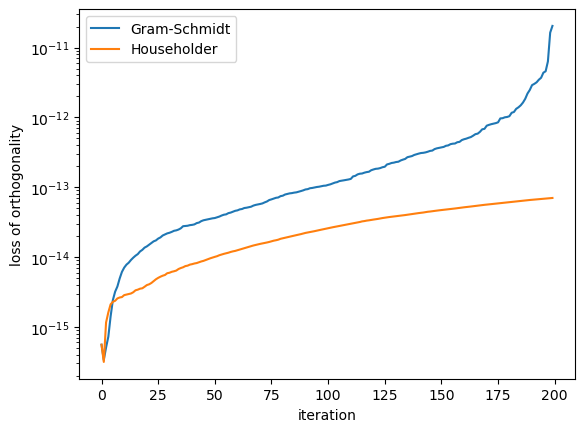

In [3]:
import matplotlib.pyplot as plt

def orthogonality_loss(Q):
    n = Q.shape[1]
    return np.linalg.norm(np.dot(Q.T, Q) - np.eye(n))

sizes = range(1, 201)
loss_gs, loss_hh = [], []
# sizes = range(4, 1001)
np.random.seed(0)
A = np.random.rand(sizes[-1], sizes[-1])
Q1, R1 = qr_gramschmidt(A)
Q2, R2 = qr_householder(A)
for n in sizes:
    loss_gs.append(orthogonality_loss(Q1[:,:n]))
    loss_hh.append(orthogonality_loss(Q2[:,:n]))


fig, ax = plt.subplots()
plt.semilogy(loss_gs, label='Gram-Schmidt')
plt.semilogy(loss_hh, label='Householder')
plt.legend()
plt.xlabel('iteration')
plt.ylabel('loss of orthogonality')

from myst_nb import glue
glue("loss-of-orthogonality-plot", fig, display=False)